# Distribution Review — Normal, Binomial, Poisson, Exponential


---

## What is a probability distribution?

A probability distribution is a model that describes **how likely different outcomes are**
for a random variable. Instead of saying "I don't know what will happen", a distribution
lets you say "here is the full picture of what could happen and how often".

Every distribution covered here answers a different real-world question:

| Distribution | The question it answers | Example |
|-------------|------------------------|---------|
| **Normal** | What is the spread of a natural measurement? | How tall are adults? |
| **Binomial** | How many successes in n fixed trials? | How many heads in 20 flips? |
| **Poisson** | How many events happen in a fixed interval? | How many emails per hour? |
| **Exponential** | How long until the next event? | How long until the next customer arrives? |

---

## When do I use which distribution?

Ask yourself these three questions in order:

```
1. Is my variable continuous (any decimal) or discrete (whole numbers only)?
   │
   ├── DISCRETE (counts: 0, 1, 2, 3...)
   │     │
   │     ├── Do I have a fixed number of trials n?
   │     │     YES → Binomial       ("I flip a coin 20 times")
   │     │     NO  → Poisson        ("calls arrive throughout the day")
   │     │
   │
   └── CONTINUOUS (any value: 1.73m, 0.0041 hrs...)
         │
         ├── Am I measuring a wait time between events?
         │     YES → Exponential    ("time until next customer")
         │     NO  → Normal         ("heights, scores, errors")
```

---

## Which Python library do I use?

Everything in this notebook comes from **scipy.stats** — one import covers all four:

```python
from scipy.stats import norm, binom, poisson, expon
```

Each distribution object gives you the same three core methods:

| Method | What it does | When to use it |
|--------|-------------|----------------|
| `.pdf(x)` / `.pmf(k)` | height of curve at x, or probability of exactly k | **plotting only** (pdf) or exact count questions (pmf) |
| `.cdf(x)` | P(X ≤ x) — area to the LEFT | "less than or equal to" questions |
| `.ppf(q)` | inverse of cdf — give it a probability, get back x | "what value marks the top X%?" questions |

> **pdf vs pmf:** continuous distributions (Normal, Exponential) use `pdf`.
> Discrete distributions (Binomial, Poisson) use `pmf`.
> The idea is the same — `pdf` gives a curve height, `pmf` gives an exact bar height.

---

## What to expect in each section

Each distribution below follows the same four steps:

1. **Intuition** — plain English, no formulas yet
2. **Formula breakdown** — each piece of the formula explained, then connected to scipy
3. **Worked example** — a real scenario with questions answered step by step, each with its own graph
4. **Your turn** — fill-in-the-blank exercises with hints

---

In [1]:
# Run this first — all imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm, binom, poisson, expon
from scipy import stats

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Ready!')

Ready!


---
## Part 1 — Normal Distribution

### The intuition

Imagine measuring the height of 10,000 people. Most are somewhere in the middle. Very few are extremely tall or extremely short. That natural clustering around a centre, falling off symmetrically, is the Normal distribution.

**Use it when:**
- Your variable is *continuous* (can take any decimal value)
- Values cluster symmetrically around a mean
- Key words: *heights, weights, test scores, errors, measurements*

**Parameters:**
| Symbol | Name | Controls |
|--------|------|----------|
| μ (mu) | Mean | Where the bell is centred |
| σ (sigma) | Std deviation | How wide / spread out the bell is |

**Formula:** $f(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$

---

### The three questions you will always be asked

Every Normal distribution problem is really one of these three questions.
Knowing which one you are facing tells you exactly which scipy function to use.

**Question type 1 — "What fraction is below/above a value?"**
> *"What fraction of students scored below 80?"*  
> *"What fraction of adults are taller than 190 cm?"*

This is `norm.cdf()` — it gives you the area to the LEFT of a value.

```
         ████████░░░
    ─────────|──────────
            80
    P(X ≤ 80) = norm.cdf(80, loc=μ, scale=σ)
```

- Below / less than → `norm.cdf(x, ...)`
- Above / more than → `1 - norm.cdf(x, ...)` (flip it)
- Between two values → `norm.cdf(b, ...) - norm.cdf(a, ...)`

---

**Question type 2 — "What value marks a given percentile?"**
> *"What score puts a student in the top 10%?"*  
> *"What is the cutoff for the bottom 25%?"*

This is `norm.ppf()` — the **inverse** of cdf. You give it a probability, it gives back the x value.

```
    ppf(0.90, ...) → answers: "what x has 90% of area to its left?"
```

- "Top 10%" → P(X ≤ x) = 0.90 → `norm.ppf(0.90, ...)`
- "Bottom 25%" → P(X ≤ x) = 0.25 → `norm.ppf(0.25, ...)`
- "Middle 95%" → find both cutoffs: `norm.ppf(0.025, ...)` and `norm.ppf(0.975, ...)`

---

**Question type 3 — "What does the distribution look like?"**
> *"Plot the distribution of exam scores."*

This is `norm.pdf()` — it gives the **height** of the curve at each x.  
You never use pdf() to get a probability directly. It is only for plotting.

```python
x = np.linspace(30, 110, 300)   # x values to plot
y = norm.pdf(x, loc=μ, scale=σ) # height of curve at each x
plt.plot(x, y)
```

---

### Quick reference

| I want to know... | scipy function | Example |
|---|---|---|
| P(X ≤ x) | `norm.cdf(x, loc=μ, scale=σ)` | fraction below 80 |
| P(X > x) | `1 - norm.cdf(x, ...)` | fraction above 80 |
| P(a ≤ X ≤ b) | `norm.cdf(b,...) - norm.cdf(a,...)` | fraction between 60 and 80 |
| x given P(X ≤ x) = q | `norm.ppf(q, loc=μ, scale=σ)` | top 10% cutoff |
| height of curve at x | `norm.pdf(x, loc=μ, scale=σ)` | for plotting only |


### Breaking down the formula

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\, e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

This looks scary. Let's read it left to right in plain English.

**Part 1 — the scaling factor:** $\dfrac{1}{\sigma\sqrt{2\pi}}$

This is just a number that makes the total area under the curve equal exactly 1  
(all probabilities must add up to 1). You never compute this by hand — scipy does it.  
Notice: larger σ → smaller scaling factor → the curve is flatter and wider.

**Part 2 — the exponent:** $-\dfrac{1}{2}\left(\dfrac{x - \mu}{\sigma}\right)^2$

This is the heart of the formula. Break it down step by step:

| Piece | What it means |
|-------|---------------|
| $x - \mu$ | How far is x from the centre? (distance from mean) |
| $\dfrac{x-\mu}{\sigma}$ | Divide by σ to get a *standardised* distance — in units of std deviations |
| $\left(\cdots\right)^2$ | Square it — so it is always positive, and large distances get penalised more |
| $-\dfrac{1}{2}(\cdots)$ | Negative sign — bigger distance → smaller exponent → curve drops toward zero |

**Part 3 — putting it together:** $e^{\text{(negative number)}}$

$e^0 = 1$ (maximum, at x = μ, the peak)  
$e^{\text{large negative}} \approx 0$ (tails, far from the mean)  
This is exactly the bell shape — highest at the centre, decaying symmetrically outward.

**The 68-95-99.7 rule** comes directly from this formula:
- Within ±1σ of mean → 68% of area
- Within ±2σ of mean → 95% of area  
- Within ±3σ of mean → 99.7% of area

---

### From formula to scipy — what function do I use?

The formula gives the **height** of the curve at one point x — that is `norm.pdf()`.  
But height alone is not a probability. To get probabilities you need the **area** under the curve, which is what `norm.cdf()` computes.

| Question | Plain English | scipy function | What it computes |
|----------|--------------|----------------|------------------|
| f(x) | height of curve at x | `norm.pdf(x, loc=μ, scale=σ)` | the formula directly — used for **plotting only** |
| P(X ≤ x) | fraction below x | `norm.cdf(x, loc=μ, scale=σ)` | area under curve from −∞ to x |
| P(X > x) | fraction above x | `1 - norm.cdf(x, loc=μ, scale=σ)` | total area (1) minus left tail |
| P(a ≤ X ≤ b) | fraction between a and b | `norm.cdf(b,...) - norm.cdf(a,...)` | area from a to b |
| x given P(X ≤ x) = q | what value has q% below it? | `norm.ppf(q, loc=μ, scale=σ)` | inverse of cdf — give it a probability, get back x |

**PDF vs CDF visualised:**

```
PDF — norm.pdf()          CDF — norm.cdf()
gives HEIGHT at one x     gives AREA to the LEFT of x

     ▲                         1 ──────────────╮
     │   ╭───╮                 │              ╱
     │  ╱     ╲                │            ╱
     │ ╱       ╲               │          ╱
     │╱         ╲              │        ╱
─────┼─────────────→        0 ─┼──────╯────────→
              x                          x
```

> `pdf` alone never gives a probability — you always need `cdf` or an area calculation for that.


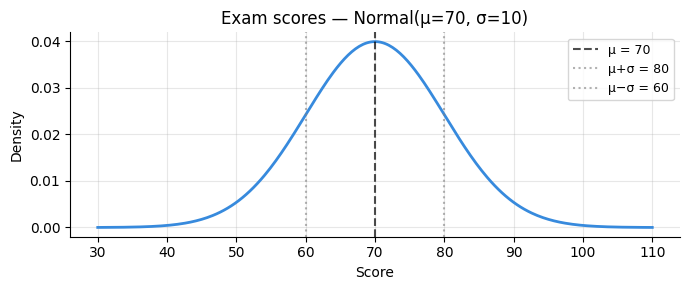

Mean  = 70   — the peak of the curve
Std   = 10   — 68% of scores fall between 60 and 80


In [2]:
# WORKED EXAMPLE — Normal distribution
# Scenario: exam scores follow Normal(μ=70, σ=10)

import math

mu    = 70   # mean  — the centre of the bell curve, where most scores cluster
sigma = 10   # std deviation — how spread out scores are around the mean

# k_vals: we evaluate the curve at 300 evenly spaced points between 30 and 110
x = np.linspace(30, 110, 300)
# norm.pdf gives the HEIGHT of the curve at each x — used only for plotting
y = norm.pdf(x, loc=mu, scale=sigma)

# ── Plot — just the shape ────────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.axvline(mu,         color='black', linestyle='--', alpha=0.7, label=f'μ = {mu}')
plt.axvline(mu+sigma,   color='gray',  linestyle=':',  alpha=0.6, label=f'μ+σ = {mu+sigma}')
plt.axvline(mu-sigma,   color='gray',  linestyle=':',  alpha=0.6, label=f'μ−σ = {mu-sigma}')
plt.xlabel('Score')
plt.ylabel('Density')
plt.title('Exam scores — Normal(μ=70, σ=10)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mean  = {mu}   — the peak of the curve')
print(f'Std   = {sigma}   — 68% of scores fall between {mu-sigma} and {mu+sigma}')


#### Q1 — What fraction of students scored 80 or below?

"80 or below" = left tail up to 80 → use `norm.cdf()`

In [ ]:
# Q1: P(X ≤ 80)
q1 = norm.cdf(80, loc=mu, scale=sigma)


print(f'norm.cdf(80, μ=70, σ=10) = {q1:.4f}')
print(f'→ {q1*100:.1f}% of students scored 80 or below.')


In [ ]:
# Q1 — graph: shade LEFT of 80
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.fill_between(x, y, where=(x <= 80), alpha=0.35, color='#378ADD', label=f'P(X ≤ 80) = {norm.cdf(80,mu,sigma):.4f}')
plt.axvline(80, color='red', linestyle='--')
plt.title('Q1 — P(X ≤ 80): shaded = left tail up to 80')
plt.xlabel('Score'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()


#### Q2 — What fraction scored above 90?

"above 90" = right tail. CDF gives the left tail, so flip it: `1 - norm.cdf()`

In [ ]:
# Q2: P(X > 90)
q2 = 1 - norm.cdf(90, loc=mu, scale=sigma)
print(f'1 - norm.cdf(90, μ=70, σ=10) = {q2:.4f}')
print(f'→ Only {q2*100:.1f}% scored above 90.  (90 is 2σ above the mean — always rare)')


In [ ]:
# Q2 — graph: shade RIGHT of 90
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.fill_between(x, y, where=(x > 90), alpha=0.35, color='#e74c3c', label=f'P(X > 90) = {1-norm.cdf(90,mu,sigma):.4f}')
plt.axvline(90, color='red', linestyle='--')
plt.title('Q2 — P(X > 90): shaded = right tail from 90')
plt.xlabel('Score'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()


#### Q3 — What fraction scored between 60 and 80?

"between a and b" = `norm.cdf(b) - norm.cdf(a)` — area up to 80 minus area up to 60

In [ ]:
# Q3: P(60 ≤ X ≤ 80)
area_up_to_80 = norm.cdf(80, loc=mu, scale=sigma)
area_up_to_60 = norm.cdf(60, loc=mu, scale=sigma)
q3 = area_up_to_80 - area_up_to_60
print(f'norm.cdf(80,...) - norm.cdf(60,...)')
print(f'= {area_up_to_80:.4f} - {area_up_to_60:.4f} = {q3:.4f}')
print(f'→ {q3*100:.1f}% scored between 60 and 80.  (60 and 80 are ±1σ → always ≈ 68%)')


In [ ]:
# Q3 — graph: shade slice between 60 and 80
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.fill_between(x, y, where=(x >= 60) & (x <= 80), alpha=0.35, color='#BA7517', label=f'P(60≤X≤80) = {norm.cdf(80,mu,sigma)-norm.cdf(60,mu,sigma):.4f}')
plt.axvline(60, color='red', linestyle='--')
plt.axvline(80, color='red', linestyle='--')
plt.title('Q3 — P(60 ≤ X ≤ 80): shaded = slice between two values')
plt.xlabel('Score'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()


#### Q4 — What score marks the top 10%?

"top 10%" means 90% scored below → we know the probability and want the x value → use `norm.ppf()`

In [ ]:
# Q4: top 10% cutoff
q4 = norm.ppf(0.90, loc=mu, scale=sigma)

print(f'norm.ppf(0.90, μ=70, σ=10) = {q4:.2f}')
print(f'→ Students who scored above {q4:.1f} are in the top 10%.')
print(f'  (ppf is the inverse of cdf — give it a probability, it gives back the x value)')


In [ ]:
# Q4 — graph: shade top 10% region
cutoff = norm.ppf(0.90, mu, sigma)
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.fill_between(x, y, where=(x >= cutoff), alpha=0.35, color='#1D9E75', label=f'top 10% — above {cutoff:.1f}')
plt.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff:.1f}')
plt.title('Q4 — top 10%: shaded = rightmost 10% of area')
plt.xlabel('Score'); plt.ylabel('Density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()


---
### Exercise 1a — Normal distribution

Adult male heights follow Normal(μ=175 cm, σ=7 cm).

Fill in each cell below. Read the hint before touching the code.

In [ ]:
# Setup — run this first
mu_ex    = ___   # mean height given in the scenario
sigma_ex = ___   # std deviation given in the scenario


**Q1** — What fraction of men are shorter than 185 cm?

*Hint: "shorter than" = left tail = direct `cdf`*

In [ ]:
# Q1: P(X < 185)
q1 = norm.___(185, mu_ex, sigma_ex)
print(f'Q1 P(X < 185) = {q1:.4f}')
# Answer: norm.cdf(185,...) ≈ 0.9234


**Q2** — What fraction of men are taller than 190 cm?

*Hint: "taller than" = right tail → total area is 1, so right tail = `1 - cdf`*

In [ ]:
# Q2: P(X > 190)
q2 = 1 - norm.___(190, mu_ex, sigma_ex)
print(f'Q2 P(X > 190) = {q2:.4f}')
# Answer: 1 - norm.cdf(190,...) ≈ 0.0161


**Q3** — What height marks the tallest 5%?

*Hint: "tallest 5%" means 95% are below that height → P(X ≤ x) = 0.95 → use `ppf` (inverse of cdf)*

In [ ]:
# Q3: top 5% cutoff
q3 = norm.ppf(___, mu_ex, sigma_ex)   # fill in the probability
print(f'Q3 Top 5% cutoff = {q3:.2f} cm')




# Answer: norm.ppf(0.95,...) ≈ 186.51 cm


**Q4** — What fraction fall between 168 cm and 182 cm?

*Hint: "between a and b" = area up to b MINUS area up to a → `cdf(b) - cdf(a)`*

In [ ]:
# Q4: P(168 < X < 182)
q4 = norm.cdf(___, mu_ex, sigma_ex) - norm.cdf(___, mu_ex, sigma_ex)
#              ↑ upper bound                    ↑ lower bound
print(f'Q4 P(168 < X < 182) = {q4:.4f}')
# Answer: norm.cdf(182,...) - norm.cdf(168,...) ≈ 0.6827  (notice: ≈ 68% — the ±1σ band!)


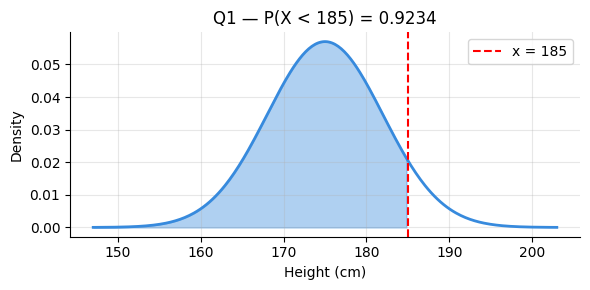

In [ ]:
# Q1: P(X < 185) — shade LEFT of 185
mu_ex, sigma_ex = 175, 7
x = np.linspace(mu_ex - 4*sigma_ex, mu_ex + 4*sigma_ex, 300)
y = norm.pdf(x, loc=mu_ex, scale=sigma_ex)

plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#378ADD', linewidth=2)
plt.fill_between(x, y, where=(x <= 185), alpha=0.4, color='#378ADD')
plt.axvline(185, color='red', linestyle='--', label='x = 185')
plt.title(f'Q1 — P(X < 185) = {norm.cdf(185, mu_ex, sigma_ex):.4f}')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — Binomial Distribution

### The intuition

You run an experiment with a fixed number of trials. Each trial has exactly two outcomes — success or failure — with the same probability every time. You count the total number of successes.

**Use it when:**
- Fixed number of trials `n` (you decide this upfront)
- Each trial is independent, with the same probability `p`
- You count *how many* succeed
- Key words: *flips, trials, tests, n items inspected*

**Parameters:**
| Symbol | Name | Meaning |
|--------|------|---------|
| n | Trials | How many times you run the experiment |
| p | Success probability | Chance of success on each trial |

**Formula:** $P(X=k) = \binom{n}{k}\, p^k\,(1-p)^{n-k}$

**Mean = n·p,  Variance = n·p·(1−p)**

**Python:**
```python
from scipy.stats import binom
binom.pmf(k, n, p)    # P(X = k)  — exactly k successes
binom.cdf(k, n, p)    # P(X ≤ k)  — k or fewer successes
```

### Breaking down the formula

$$P(X = k) = \\binom{n}{k}\\, p^k\\,(1-p)^{n-k}$$

This formula has **three separate parts** multiplied together. Each part answers a different question.

**Example:** flip a coin 5 times (n=5, p=0.5). What is P(exactly 3 heads)?

---

**Part 1 — $\\binom{n}{k}$ — the combination ("n choose k")**

$$\\binom{n}{k} = \\frac{n!}{k!\\,(n-k)!}$$

*Question it answers:* in how many different **orders** can k successes appear in n trials?

For 3 heads in 5 flips: HHHTT, HHTHT, HTHHT, ... there are $\\binom{5}{3} = 10$ different orderings.

| n! means | Example |
|----------|----------|
| n factorial = n × (n-1) × ... × 1 | 5! = 5×4×3×2×1 = 120 |

---

**Part 2 — $p^k$ — probability of the successes**

*Question it answers:* what is the probability of getting k successes in a row?

Each flip is independent, so we multiply: $p \\times p \\times \\cdots = p^k$  
For 3 heads: $0.5^3 = 0.125$

---

**Part 3 — $(1-p)^{n-k}$ — probability of the failures**

*Question it answers:* what is the probability of the remaining (n-k) trials all being failures?

For 2 tails: $(1-0.5)^{5-3} = 0.5^2 = 0.25$

---

**Putting it all together:**

$$P(X=3) = \\underbrace{10}_{\\text{orderings}} \\times \\underbrace{0.125}_{\\text{3 heads}} \\times \\underbrace{0.25}_{\\text{2 tails}} = 0.3125$$

> Think of it as: *(how many ways)* × *(chance of each success)* × *(chance of each failure)*

---

### From formula to scipy — what function do I use?

The formula above computes **one specific bar** — P(X = k) for a single value of k.  
In practice you will always use one of three scipy functions depending on the question:

| Question | Plain English | scipy function | What it computes |
|----------|--------------|----------------|------------------|
| P(X = k) | exactly k successes | `binom.pmf(k, n, p)` | runs the formula once for that k |
| P(X ≤ k) | k or fewer successes | `binom.cdf(k, n, p)` | sums pmf(0) + pmf(1) + ... + pmf(k) |
| P(X ≥ k) | k or more successes | `1 - binom.cdf(k-1, n, p)` | 1 minus the left tail up to k-1 |
| P(a ≤ X ≤ b) | between a and b | `binom.cdf(b, n, p) - binom.cdf(a-1, n, p)` | right slice minus left slice |

**PMF vs CDF visualised:**

```
Bars = pmf values

  P(X = 3)           P(X ≤ 3)              P(X ≥ 3)
  pmf(3) only        pmf(0)+pmf(1)          1 - pmf(0)
                     +pmf(2)+pmf(3)           - pmf(1)
                                              - pmf(2)

  ░░░█░░░░░          ████░░░░░             ░░░█████░
  0 1 2 3 4 5        0 1 2 3 4 5           0 1 2 3 4 5
```

**The key difference from Normal:**  
In the Normal distribution, CDF is a smooth area under a curve.  
In Binomial, CDF is just **adding up individual bars** — because k can only be a whole number.
This is why `P(X < 5)` and `P(X ≤ 4)` are identical in Binomial (both exclude 5),  
and why `P(X ≥ 5) = 1 - binom.cdf(4)` not `1 - binom.cdf(5)`.


In [3]:
# FORMULA WALKTHROUGH — Binomial distribution
# Let's compute P(X=3) for n=5, p=0.5 step by step

import math   # needed for math.comb() and math.factorial()

n, p, k = 5, 0.5, 3

# Part 1: C(n, k) — the combination
# math.comb(n, k) computes n! / (k! * (n-k)!) for us
combinations = math.comb(n, k)
print(f'Part 1 — C({n},{k}) = {n}! / ({k}! × {n-k}!) = {combinations} orderings')

# Part 2: p^k — probability of k successes
p_successes = p**k
print(f'Part 2 — p^k = {p}^{k} = {p_successes}')

# Part 3: (1-p)^(n-k) — probability of (n-k) failures
p_failures = (1 - p)**(n - k)
print(f'Part 3 — (1-p)^(n-k) = {1-p}^{n-k} = {p_failures}')

# Combine all three parts
manual_result = combinations * p_successes * p_failures
print(f'\nManual: {combinations} × {p_successes} × {p_failures} = {manual_result}')

# Compare to scipy
scipy_result = binom.pmf(k, n, p)
print(f'scipy binom.pmf({k}, {n}, {p}) = {scipy_result}')
print(f'Match: {abs(manual_result - scipy_result) < 1e-10}')
print()
print('Now try it yourself: change n=10, p=0.3, k=4 and rerun.')
print('Check: does your manual answer match binom.pmf(4, 10, 0.3)?')

Part 1 — C(5,3) = 5! / (3! × 2!) = 10 orderings
Part 2 — p^k = 0.5^3 = 0.125
Part 3 — (1-p)^(n-k) = 0.5^2 = 0.25

Manual: 10 × 0.125 × 0.25 = 0.3125
scipy binom.pmf(3, 5, 0.5) = 0.3124999999999998
Match: True

Now try it yourself: change n=10, p=0.3, k=4 and rerun.
Check: does your manual answer match binom.pmf(4, 10, 0.3)?


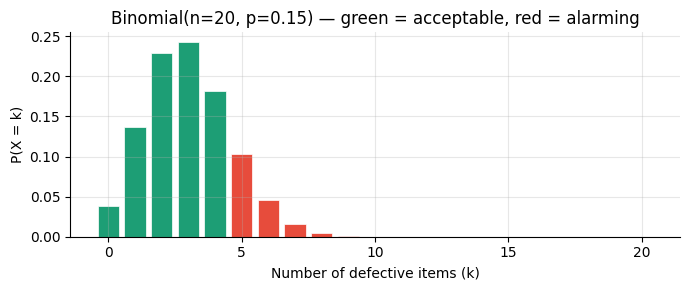

Mean = n·p            = 20 × 0.15 = 3.0
Std  = √(n·p·(1-p))  = 1.597
→ We expect around 3.0 defects per batch, give or take ~1.6.


In [4]:
# WORKED EXAMPLE — Binomial distribution
# Scenario: a quality inspector checks 20 items; each has a 15% defect chance.

n = 20      # number of trials — items inspected (fixed upfront)
p = 0.15    # probability of success per trial — here "success" means defective

# k_vals: every possible outcome — 0 defects, 1, 2, ... up to n
k_vals  = np.arange(0, n + 1)
pmf_vals = binom.pmf(k_vals, n, p)   # P(X = k) for each k

# ── Plot — just the shape ────────────────────────────────────────────────────
# Green = acceptable (k < 5),  Red = alarming (k ≥ 5)
colors = ['#e74c3c' if k >= 5 else '#1D9E75' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors, edgecolor='white', linewidth=0.5)
plt.xlabel('Number of defective items (k)')
plt.ylabel('P(X = k)')
plt.title(f'Binomial(n={n}, p={p}) — green = acceptable, red = alarming')
plt.tight_layout()
plt.show()

mean = n * p
std  = np.sqrt(n * p * (1 - p))
print(f'Mean = n·p            = {n} × {p} = {mean}')
print(f'Std  = √(n·p·(1-p))  = {std:.3f}')
print(f'→ We expect around {mean} defects per batch, give or take ~{std:.1f}.')


#### Q1 — What is the probability of zero defects?

"exactly 0" = one specific bar → use `binom.pmf()`

In [5]:
# Q1: P(X = 0)
q1 = binom.pmf(0, n, p)
print(f'binom.pmf(0, n={n}, p={p}) = {q1:.4f}')
print(f'→ {q1*100:.1f}% chance of a perfectly clean batch.')


binom.pmf(0, n=20, p=0.15) = 0.0388
→ 3.9% chance of a perfectly clean batch.


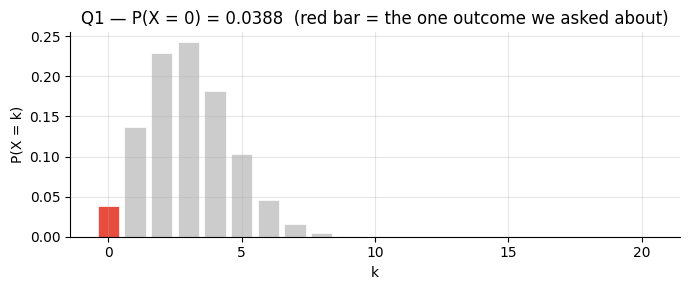

In [6]:
# Q1 — graph: highlight the single bar at k=0
colors_q1 = ['#e74c3c' if k == 0 else '#cccccc' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q1, edgecolor='white', linewidth=0.5)
plt.title(f'Q1 — P(X = 0) = {binom.pmf(0,n,p):.4f}  (red bar = the one outcome we asked about)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


#### Q2 — What is the probability of 3 or fewer defects?

"3 or fewer" = left tail up to 3 → use `binom.cdf()`

In [8]:
# Q2: P(X ≤ 3)
q2 = binom.cdf(3, n, p)
print(f'binom.cdf(3, n={n}, p={p}) = {q2:.4f}')
print(f'→ {q2*100:.1f}% of batches will have 3 or fewer defects.')


binom.cdf(3, n=20, p=0.15) = 0.6477
→ 64.8% of batches will have 3 or fewer defects.


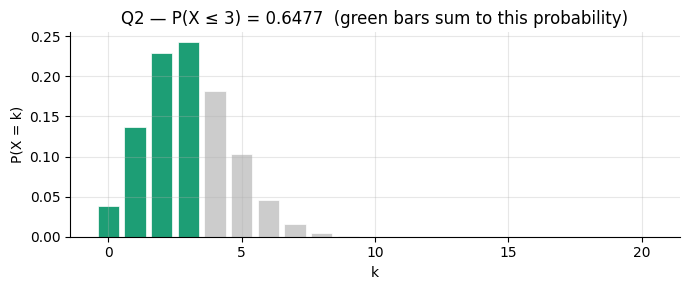

In [9]:
# Q2 — graph: highlight bars k=0 to k=3
colors_q2 = ['#1D9E75' if k <= 3 else '#cccccc' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q2, edgecolor='white', linewidth=0.5)
plt.title(f'Q2 — P(X ≤ 3) = {binom.cdf(3,n,p):.4f}  (green bars sum to this probability)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


#### Q3 — What is the probability of 5 or more defects?

"5 or more" = right tail. Flip the CDF: `1 - binom.cdf(4)` — note we use 4, not 5, so that 5 is included in the tail.

In [10]:
# Q3: P(X ≥ 5)
q3 = 1 - binom.cdf(4, n, p)
print(f'1 - binom.cdf(4, n={n}, p={p})')
print(f'= 1 - {binom.cdf(4,n,p):.4f} = {q3:.4f}')
print(f'→ {q3*100:.1f}% chance of 5 or more defects.')
print(f'  (Why cdf(4) and not cdf(5)? Because we want 5 INCLUDED in the right tail.)')


1 - binom.cdf(4, n=20, p=0.15)
= 1 - 0.8298 = 0.1702
→ 17.0% chance of 5 or more defects.
  (Why cdf(4) and not cdf(5)? Because we want 5 INCLUDED in the right tail.)


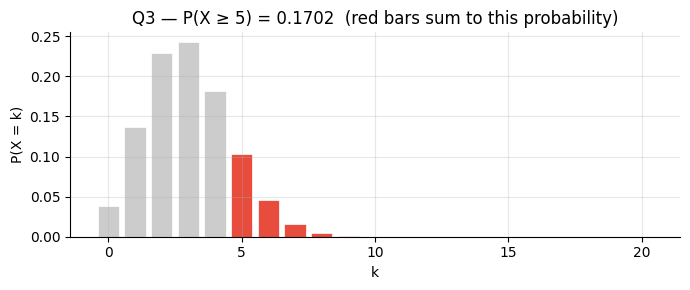

In [11]:
# Q3 — graph: highlight bars k≥5
colors_q3 = ['#e74c3c' if k >= 5 else '#cccccc' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q3, edgecolor='white', linewidth=0.5)
plt.title(f'Q3 — P(X ≥ 5) = {1-binom.cdf(4,n,p):.4f}  (red bars sum to this probability)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


#### Q4 — What is the probability of between 2 and 6 defects?

"between a and b" (discrete) = `cdf(b) - cdf(a-1)` — we use `a-1` to keep `a` itself included.

In [12]:
# Q4: P(2 ≤ X ≤ 6)
q4 = binom.cdf(6, n, p) - binom.cdf(1, n, p)
print(f'binom.cdf(6,...) - binom.cdf(1,...)')
print(f'= {binom.cdf(6,n,p):.4f} - {binom.cdf(1,n,p):.4f} = {q4:.4f}')
print(f'→ {q4*100:.1f}% of batches fall between 2 and 6 defects.')
print(f'  (We subtract cdf(1) not cdf(2) so that k=2 is included in the answer.)')


binom.cdf(6,...) - binom.cdf(1,...)
= 0.9781 - 0.1756 = 0.8025
→ 80.3% of batches fall between 2 and 6 defects.
  (We subtract cdf(1) not cdf(2) so that k=2 is included in the answer.)


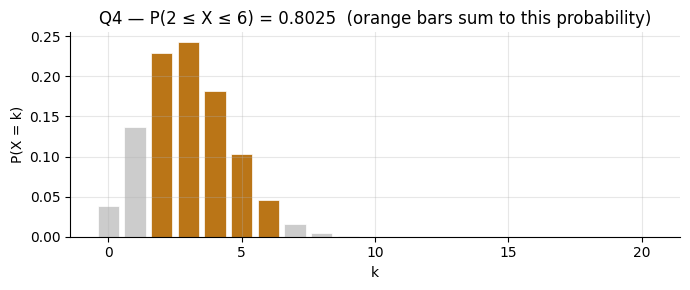

In [13]:
# Q4 — graph: highlight bars k=2 to k=6
colors_q4 = ['#BA7517' if 2 <= k <= 6 else '#cccccc' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q4, edgecolor='white', linewidth=0.5)
plt.title(f'Q4 — P(2 ≤ X ≤ 6) = {binom.cdf(6,n,p)-binom.cdf(1,n,p):.4f}  (orange bars sum to this probability)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


In [ ]:
# EXERCISE 2a — Fill in the blanks
#
# A call centre agent answers 25 calls per shift.
# Each call has a 30% chance of resulting in a sale.
#
# Q1: What is the probability of exactly 8 sales?
# Q2: What is the probability of fewer than 5 sales?
# Q3: What is the probability of 10 or more sales?
# Q4: What is the expected number of sales per shift?

n_ex = ___
p_ex = ___

q1 = binom.___(8, n_ex, p_ex)
q2 = binom.cdf(___, n_ex, p_ex)           # fewer than 5 means ≤ 4
q3 = 1 - binom.cdf(___, n_ex, p_ex)       # 10 or more means NOT ≤ 9
q4 = ___ * ___

print(f'Q1 P(X = 8)   = {q1:.4f}')
print(f'Q2 P(X < 5)   = {q2:.4f}')
print(f'Q3 P(X ≥ 10)  = {q3:.4f}')
print(f'Q4 Expected   = {q4}')

# ANSWERS:
# n=25, p=0.30
# Q1: binom.pmf(8, 25, 0.3) ≈ 0.1651
# Q2: binom.cdf(4, 25, 0.3) ≈ 0.0905
# Q3: 1 - binom.cdf(9, 25, 0.3) ≈ 0.1894
# Q4: 25 * 0.30 = 7.5

In [ ]:
# EXERCISE 2b — Effect of p on the shape
#
# Plot 3 Binomial distributions with n=20 and p = 0.2, 0.5, 0.8
# What do you notice about the shape as p changes?

n_ex = 20
p_vals = [___, ___, ___]        # fill in 0.2, 0.5, 0.8
colors = ['#378ADD', '#1D9E75', '#D85A30']
k_vals = np.arange(0, n_ex + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, p, c in zip(axes, p_vals, colors):
    pmf = binom.pmf(k_vals, n_ex, ___)
    ax.bar(k_vals, pmf, color=c, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_title(f'n={n_ex}, p={p}')
    ax.set_xlabel('k')

axes[0].set_ylabel('P(X = k)')
plt.suptitle('How p changes the Binomial shape')
plt.tight_layout()
plt.show()

# OBSERVATION to write here:
# p=0.2 → skewed right  (most mass on low k)
# p=0.5 → symmetric bell
# p=0.8 → skewed left   (most mass on high k)

---
## Part 3 — Poisson Distribution

### The intuition

Imagine a busy coffee shop. On average, 3 customers walk in every 5 minutes. You can't say *which* second a customer will arrive, but you know the *average rate*. The Poisson distribution tells you the probability of getting exactly k customers in that 5-minute window.

**Use it when:**
- Counting events in a fixed interval (time, area, volume)
- Events are *rare* and *independent*
- No fixed `n` — the count can be 0, 1, 2, 3, ...
- Key words: *per hour, per day, per km², arrivals, accidents, emails*

> **Poisson vs Binomial decision:** Do you have a fixed number of trials `n`? → Binomial. Is it events arriving over time with no fixed `n`? → Poisson.

**Parameters:**
| Symbol | Name | Meaning |
|--------|------|---------|
| λ (lambda) | Rate | Average number of events per interval |

**Formula:** $P(X=k) = \frac{\lambda^k e^{-\lambda}}{k!}$

**Mean = λ,  Variance = λ**  (same! this is a signature of Poisson)

**Python:**
```python
from scipy.stats import poisson
poisson.pmf(k, mu=λ)    # P(X = k)
poisson.cdf(k, mu=λ)    # P(X ≤ k)
```

### Breaking down the formula

$$P(X = k) = \frac{\lambda^k \cdot e^{-\lambda}}{k!}$$

Three parts again — each one has a clear job.

**Example:** a hospital gets λ=4 emergency calls per hour. What is P(exactly 6 calls)?

---

**Part 1 — $\lambda^k$ — how likely is it to see k events given the rate?**

λ is the average rate. $\lambda^k$ grows when k is close to λ (likely) and shrinks when k is far from λ (unlikely).  
For our example: $4^6 = 4096$

---

**Part 2 — $e^{-\lambda}$ — the "decay" factor**

$e^{-\lambda}$ is always between 0 and 1. It shrinks the probability to keep the total sum equal to 1.  
Think of it as: *"given how often events happen in total, how much probability is left for this specific k?"*  
For λ=4: $e^{-4} \approx 0.0183$

---

**Part 3 — $k!$ — dividing by the number of orderings**

Unlike the Binomial, the Poisson doesn't care about order. Dividing by k! removes the overcounting.  
For k=6: $6! = 720$

---

**Putting it all together:**

$$P(X=6) = \frac{4^6 \cdot e^{-4}}{6!} = \frac{4096 \times 0.0183}{720} \approx 0.1042$$

> Notice: the formula has **no n**. That is what makes Poisson different from Binomial —  
> there is no fixed number of trials, just a rate λ over an interval.

---

### From formula to scipy — what function do I use?

The formula computes P(X = k) for **one specific k** — that is `poisson.pmf()`.  
For anything involving ranges (≤, ≥, between), you need `poisson.cdf()` which adds up bars for you.

| Question | Plain English | scipy function | What it computes |
|----------|--------------|----------------|------------------|
| P(X = k) | exactly k events | `poisson.pmf(k, mu=λ)` | runs the formula once for that k |
| P(X ≤ k) | k or fewer events | `poisson.cdf(k, mu=λ)` | sums pmf(0) + pmf(1) + ... + pmf(k) |
| P(X > k) | more than k events | `1 - poisson.cdf(k, mu=λ)` | 1 minus left tail up to k |
| P(X ≥ k) | k or more events | `1 - poisson.cdf(k-1, mu=λ)` | 1 minus left tail up to k−1 (includes k) |
| P(a ≤ X ≤ b) | between a and b | `poisson.cdf(b, mu=λ) - poisson.cdf(a-1, mu=λ)` | right slice minus left slice |

**PMF vs CDF visualised:**

```
  P(X = 4) — pmf(4)       P(X ≤ 4) — cdf(4)       P(X ≥ 4) — 1-cdf(3)
  just the one bar         all bars up to 4          bar 4 and everything right

  ░░░░█░░░░░░░            █████░░░░░░░             ░░░█████████░
  0 1 2 3 4 5 6 7         0 1 2 3 4 5 6 7          0 1 2 3 4 5 6 7
```

**Watch out — > vs ≥ matters in discrete distributions:**

| What you want | Correct code | Common mistake |
|---------------|-------------|----------------|
| P(X > 4) — strictly more than 4 | `1 - poisson.cdf(4, mu=λ)` | using cdf(3) by mistake |
| P(X ≥ 4) — 4 or more | `1 - poisson.cdf(3, mu=λ)` | using cdf(4) — this excludes 4! |

> This is the same trap as Binomial. When in doubt, say it out loud:  
> *"I want 4 included in my answer"* → subtract everything BELOW 4 → `1 - cdf(3)`


In [ ]:
# FORMULA WALKTHROUGH — Poisson distribution
# Let's compute P(X=6) for λ=4 step by step

lam, k = 4, 6

# Part 1: λ^k
lam_k = lam**k
print(f'Part 1 — λ^k = {lam}^{k} = {lam_k}')

# Part 2: e^(-λ)
e_decay = math.exp(-lam)
print(f'Part 2 — e^(-λ) = e^(-{lam}) = {e_decay:.6f}')

# Part 3: k!
k_factorial = math.factorial(k)
print(f'Part 3 — k! = {k}! = {k_factorial}')

# Combine
manual_result = (lam_k * e_decay) / k_factorial
print(f'\nManual: ({lam_k} × {e_decay:.6f}) / {k_factorial} = {manual_result:.6f}')

# Compare to scipy
scipy_result = poisson.pmf(k, mu=lam)


print(f'scipy poisson.pmf({k}, mu={lam}) = {scipy_result:.6f}')
print(f'Match: {abs(manual_result - scipy_result) < 1e-10}')
print()
print('Notice: unlike Binomial, there is no n in the formula.')
print('Poisson only needs the average rate λ — not how many trials were run.')


Part 1 — λ^k = 4^6 = 4096
Part 2 — e^(-λ) = e^(-4) = 0.018316
Part 3 — k! = 6! = 720

Manual: (4096 × 0.018316) / 720 = 0.104196
scipy poisson.pmf(6, mu=4) = 0.104196
Match: True

Notice: unlike Binomial, there is no n in the formula.
Poisson only needs the average rate λ — not how many trials were run.


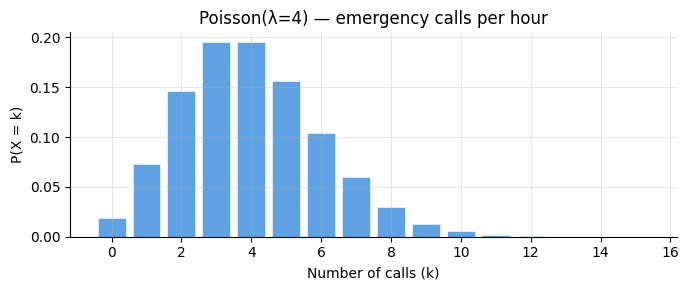

λ = 4  →  Mean = 4, Variance = 4  (always equal in Poisson!)


In [15]:
# WORKED EXAMPLE — Poisson distribution
# Scenario: a hospital receives an average of 4 emergency calls per hour.

lam = 4     # λ — the average number of events per interval (here: calls per hour)
            # this is the ONLY parameter Poisson needs — no n, no p

k_vals   = np.arange(0, 16)               # possible outcomes: 0, 1, 2, ... 15
pmf_vals = poisson.pmf(k_vals, mu=lam)    # P(X = k) for each k

# ── Plot — just the shape ────────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color='#378ADD', alpha=0.8, edgecolor='white', linewidth=0.5)
plt.xlabel('Number of calls (k)')
plt.ylabel('P(X = k)')
plt.title(f'Poisson(λ={lam}) — emergency calls per hour')
plt.tight_layout()
plt.show()

print(f'λ = {lam}  →  Mean = {lam}, Variance = {lam}  (always equal in Poisson!)')


#### Q1 — What is the probability of exactly 4 calls? (the average)

"exactly k" = one bar → use `poisson.pmf()`

In [16]:
# Q1: P(X = 4) — the most likely single outcome, but still not that probable
q1 = poisson.pmf(4, mu=lam)
print(f'poisson.pmf(4, λ={lam}) = {q1:.4f}')
print(f'→ Even the most likely outcome only happens {q1*100:.1f}% of the time.')
print(f'  Probability is spread across many possible values of k.')


poisson.pmf(4, λ=4) = 0.1954
→ Even the most likely outcome only happens 19.5% of the time.
  Probability is spread across many possible values of k.


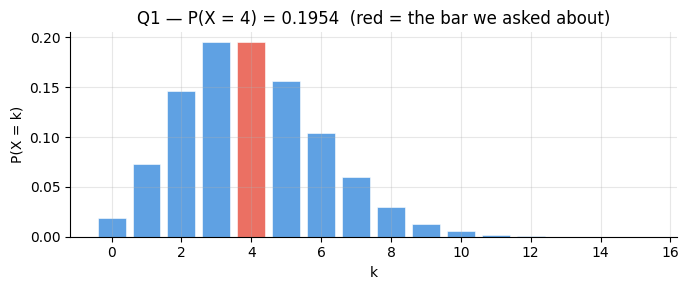

In [17]:
# Q1 — graph: highlight bar at k=4
colors_q1 = ['#e74c3c' if k == 4 else '#378ADD' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q1, alpha=0.8, edgecolor='white', linewidth=0.5)
plt.title(f'Q1 — P(X = 4) = {poisson.pmf(4,mu=lam):.4f}  (red = the bar we asked about)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


#### Q2 — What is the probability of 3 or fewer calls?

"3 or fewer" = left tail → use `poisson.cdf()`

In [ ]:
# Q2: P(X ≤ 3)
q2 = poisson.cdf(3, mu=lam)

print(f'poisson.cdf(3, λ={lam}) = {q2:.4f}')
print(f'→ {q2*100:.1f}% of hours will have 3 or fewer calls.')


poisson.cdf(3, λ=4) = 0.4335
→ 43.3% of hours will have 3 or fewer calls.


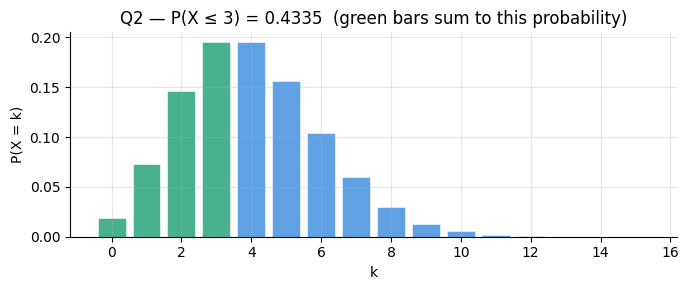

In [19]:
# Q2 — graph: highlight bars k=0 to k=3
colors_q2 = ['#1D9E75' if k <= 3 else '#378ADD' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q2, alpha=0.8, edgecolor='white', linewidth=0.5)
plt.title(f'Q2 — P(X ≤ 3) = {poisson.cdf(3,mu=lam):.4f}  (green bars sum to this probability)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


#### Q3 — What is the probability of 8 or more calls?

"8 or more" = right tail → `1 - poisson.cdf(7)` (use 7, not 8, so 8 is included)

In [20]:
# Q3: P(X ≥ 8)
q3 = 1 - poisson.cdf(7, mu=lam)
print(f'1 - poisson.cdf(7, λ={lam})')
print(f'= 1 - {poisson.cdf(7,mu=lam):.4f} = {q3:.4f}')
print(f'→ Only {q3*100:.1f}% of hours will be this busy — an unusually high load.')


1 - poisson.cdf(7, λ=4)
= 1 - 0.9489 = 0.0511
→ Only 5.1% of hours will be this busy — an unusually high load.


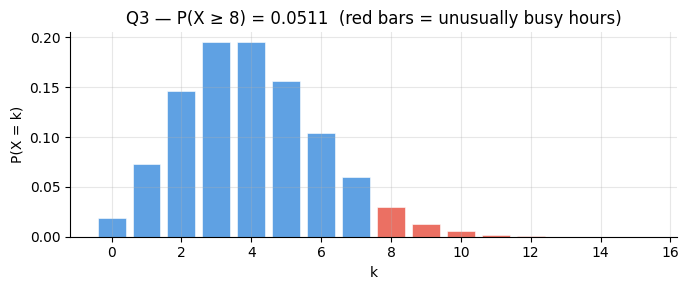

In [21]:
# Q3 — graph: highlight bars k≥8
colors_q3 = ['#e74c3c' if k >= 8 else '#378ADD' for k in k_vals]
plt.figure(figsize=(7, 3))
plt.bar(k_vals, pmf_vals, color=colors_q3, alpha=0.8, edgecolor='white', linewidth=0.5)
plt.title(f'Q3 — P(X ≥ 8) = {1-poisson.cdf(7,mu=lam):.4f}  (red bars = unusually busy hours)')
plt.xlabel('k'); plt.ylabel('P(X = k)'); plt.tight_layout(); plt.show()


In [ ]:
# EXERCISE 3a — Fill in the blanks
#
# A website receives an average of 6 visits per minute.
#
# Q1: What is the probability of exactly 6 visits in a minute?
# Q2: What is the probability of fewer than 3 visits?
# Q3: What is the probability of more than 10 visits?
# Q4: Rescale: what is λ for a 2-minute window?

lam_ex = ___    # visits per minute

q1 = poisson.___(___, mu=lam_ex)
q2 = poisson.cdf(___, mu=lam_ex)          # fewer than 3 means ≤ 2
q3 = 1 - poisson.cdf(___, mu=lam_ex)     # more than 10 means NOT ≤ 10
q4 = lam_ex * ___                         # scale λ to a 2-minute window

print(f'Q1 P(X = 6)    = {q1:.4f}')
print(f'Q2 P(X < 3)    = {q2:.4f}')
print(f'Q3 P(X > 10)   = {q3:.4f}')
print(f'Q4 λ for 2 min = {q4}')

# ANSWERS:
# lam_ex = 6
# Q1: poisson.pmf(6, mu=6) ≈ 0.1606
# Q2: poisson.cdf(2, mu=6) ≈ 0.0620
# Q3: 1 - poisson.cdf(10, mu=6) ≈ 0.0426
# Q4: 6 * 2 = 12

In [ ]:
# EXERCISE 3b — How λ scales with time
#
# Core idea: if a factory makes 2 defects per hour,
# then in 4 hours you expect 8 defects, in 8 hours you expect 16.
# λ just multiplies — the distribution shape stays the same, it shifts right.

# Step 1: set the base rate (defects per 1 hour)
lam_per_hour = ___     # fill in: 2

# Step 2: build a list of (label, λ) pairs for each time window
# We multiply the hourly rate by the number of hours to get λ for that window
windows = [
    ('1 hour',  lam_per_hour * ___),   # fill in: 1
    ('4 hours', lam_per_hour * ___),   # fill in: 4
    ('8 hours', lam_per_hour * ___),   # fill in: 8
]

# Step 3: create 3 side-by-side plots, one for each window
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, lam) in zip(axes, windows):
    # zip() pairs each ax with its (label, lam) — so ax1 gets 1hr, ax2 gets 4hr, etc.

    # Step 4: create k values to plot — we go up to 3× the mean as a safe upper limit
    k_vals = np.arange(0, lam * 3 + 1)
    # np.arange gives us whole numbers: 0, 1, 2, 3, ...
    # lam * 3 is just a practical cutoff — beyond 3× the mean, probabilities are tiny

    # Step 5: compute P(X = k) for each k using the Poisson formula
    pmf = poisson.pmf(k_vals, mu=___)   # fill in: lam

    # Step 6: draw the bar chart for this window
    ax.bar(k_vals, pmf, color='#BA7517', alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{label}  (λ = {lam})')
    ax.set_xlabel('Number of defects')

axes[0].set_ylabel('P(X = k)')
plt.suptitle('Same process, different time window — λ grows, shape stays Poisson')
plt.tight_layout()
plt.show()

# What to observe when you run this:
# - The peak shifts RIGHT as the window gets longer (more expected defects)
# - The bars spread WIDER (more uncertainty over longer windows)
# - The shape stays the same bell-like Poisson curve — it just slides and stretches

---
## Part 4 — Exponential Distribution

### The intuition

If the Poisson counts *how many events* happen per interval, the Exponential measures *how long you wait* until the next event.

**Same process, different question:**
- Poisson: "How many customers arrive in 1 hour?" (λ = 10/hour)
- Exponential: "How long until the next customer arrives?" (mean wait = 1/λ = 6 minutes)

**Use it when:**
- Measuring *waiting time* or *time between events*
- Events happen randomly and independently
- Key words: *time until, time between, lifetime, survival, wait*

**Key property — Memorylessness:**
> If you have already waited 5 minutes for a bus, the probability of waiting 5 more minutes is *exactly the same* as if you had just arrived. The past does not matter.

**Parameters:**
| Symbol | Name | Meaning |
|--------|------|---------|
| λ (rate) | Rate | Events per unit time (same λ as Poisson) |
| 1/λ | Mean | Average wait time |

**Formula:** $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$

**Python:**
```python
from scipy.stats import expon
# scipy uses scale = 1/λ  (the mean wait time)
expon.pdf(x, scale=1/λ)    # density at x
expon.cdf(x, scale=1/λ)    # P(wait ≤ x)
```

### Breaking down the formula

$$f(x) = \lambda \cdot e^{-\lambda x} \quad \text{for } x \geq 0$$

This is a **PDF** (probability density function), not a PMF — it gives the *height* of the curve at x,  
not a probability directly. To get a probability you need the **CDF** (area under the curve).

$$F(x) = P(X \leq x) = 1 - e^{-\lambda x}$$

This CDF formula is what `expon.cdf()` computes — and it's simple enough to use by hand.

---

**Part 1 — $\lambda$ — the scaling factor**

Just ensures the total area under the curve equals 1 (same role as $\frac{1}{\sigma\sqrt{2\pi}}$ in the Normal).  
Higher λ → curve starts higher and drops faster.

**Part 2 — $e^{-\lambda x}$ — the decay**

| x value | $e^{-\lambda x}$ | Meaning |
|---------|-----------------|----------|
| x = 0 | $e^0 = 1$ | Curve starts at its maximum |
| x = 1/λ (mean) | $e^{-1} \approx 0.368$ | Curve has dropped to 37% of its peak |
| x → ∞ | → 0 | Curve decays to zero (very long waits are very rare) |

**The CDF in plain English:**

$$P(X \leq x) = 1 - e^{-\lambda x}$$

- At x=0: $1 - e^0 = 0$ (probability of waiting 0 time is 0)
- As x grows: probability grows toward 1 (eventually you will always wait long enough)

**And for "greater than":** $P(X > x) = 1 - P(X \leq x) = e^{-\lambda x}$

> This is the cleanest formula in the group — you can compute $P(X > x) = e^{-\lambda x}$ in your head.

---

### From formula to scipy — what function do I use?

⚠️ **scipy uses `scale = 1/λ` (the mean wait time), NOT λ directly.**  
Always compute `mean = 1/λ` first, then pass `scale=mean` to every scipy call.

| Question | Plain English | scipy function | What it computes |
|----------|--------------|----------------|------------------|
| f(x) | height of curve at x | `expon.pdf(x, scale=1/λ)` | the PDF formula — for **plotting only** |
| P(X ≤ x) | wait is x or shorter | `expon.cdf(x, scale=1/λ)` | $1 - e^{-\lambda x}$ |
| P(X > x) | wait is longer than x | `1 - expon.cdf(x, scale=1/λ)` | $e^{-\lambda x}$ — the survival formula |
| x given P(X ≤ x) = q | wait time at percentile q | `expon.ppf(q, scale=1/λ)` | inverse CDF |

**Shortcut you can use without scipy:**

$$P(X > x) = e^{-\lambda x}$$

This is clean enough to compute in your head for round numbers:

| Scenario (λ=10/hr) | Calculation | Result |
|--------------------|------------|--------|
| P(wait > 6 min) | $e^{-10 \times 0.1} = e^{-1}$ | ≈ 0.368 |
| P(wait > 12 min) | $e^{-10 \times 0.2} = e^{-2}$ | ≈ 0.135 |
| P(wait > 30 min) | $e^{-10 \times 0.5} = e^{-5}$ | ≈ 0.007 |

**Relationship with Poisson — same λ, different question:**

| Distribution | Same process | Question asked |
|-------------|-------------|----------------|
| Poisson(λ=10) | customers arrive at 10/hr | How many arrive in 1 hour? |
| Exponential(λ=10) | customers arrive at 10/hr | How long until the next one arrives? |


In [22]:
# FORMULA WALKTHROUGH — Exponential distribution
# Compute P(wait ≤ 6 min) and P(wait > 6 min) by hand, then check with scipy

lam = 10          # 10 customers per hour
x_hours = 6/60    # 6 minutes converted to hours = 0.1

print(f'λ = {lam} per hour,  x = {x_hours} hours (= 6 minutes)')
print()

# CDF by hand: P(X ≤ x) = 1 - e^(-λx)
e_term = math.exp(-lam * x_hours)
print(f'Step 1 — compute e^(-λx) = e^(-{lam} × {x_hours}) = e^({-lam*x_hours}) = {e_term:.6f}')

p_leq = 1 - e_term
print(f'Step 2 — P(X ≤ x) = 1 - {e_term:.6f} = {p_leq:.6f}')

# Complement: P(X > x) = e^(-λx)  — no subtraction needed!
p_gt = e_term
print(f'Step 3 — P(X > x) = e^(-λx) = {p_gt:.6f}  (same e_term, no extra work)')

print()
# Compare to scipy — remember scipy uses scale = 1/λ
mean_wait = 1 / lam
scipy_cdf = expon.cdf(x_hours, scale=mean_wait)
print(f'scipy expon.cdf({x_hours}, scale={mean_wait}) = {scipy_cdf:.6f}')
print(f'Match: {abs(p_leq - scipy_cdf) < 1e-10}')
print()
print('Key shortcut: P(X > x) = e^(-λx)')
print('You can compute survival probabilities without scipy at all!')
print(f'  P(wait > 6 min)  = e^(-10 × 0.1) = e^(-1) ≈ {math.exp(-1):.4f}')
print(f'  P(wait > 12 min) = e^(-10 × 0.2) = e^(-2) ≈ {math.exp(-2):.4f}')
print(f'  P(wait > 30 min) = e^(-10 × 0.5) = e^(-5) ≈ {math.exp(-5):.4f}')


λ = 10 per hour,  x = 0.1 hours (= 6 minutes)

Step 1 — compute e^(-λx) = e^(-10 × 0.1) = e^(-1.0) = 0.367879
Step 2 — P(X ≤ x) = 1 - 0.367879 = 0.632121
Step 3 — P(X > x) = e^(-λx) = 0.367879  (same e_term, no extra work)

scipy expon.cdf(0.1, scale=0.1) = 0.632121
Match: True

Key shortcut: P(X > x) = e^(-λx)
You can compute survival probabilities without scipy at all!
  P(wait > 6 min)  = e^(-10 × 0.1) = e^(-1) ≈ 0.3679
  P(wait > 12 min) = e^(-10 × 0.2) = e^(-2) ≈ 0.1353
  P(wait > 30 min) = e^(-10 × 0.5) = e^(-5) ≈ 0.0067


λ         = 10 customers per hour
mean_wait = 1/λ = 0.1 hours = 6 minutes

Key: scipy expon always uses scale = 1/λ (the mean), not λ itself.


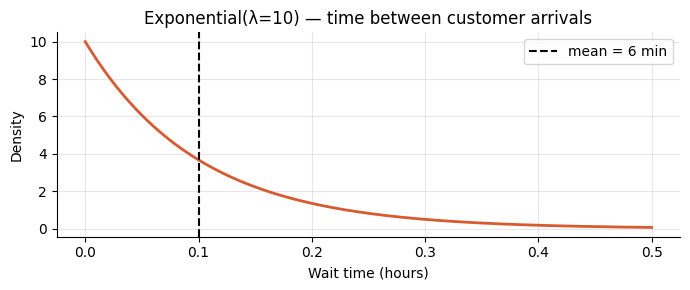

In [ ]:
# WORKED EXAMPLE — Exponential distribution
#
# Scenario: a coffee shop receives customers at a rate of 10 per hour.
#
# We are NOT asking "how many customers arrive?" — that would be Poisson.
# We are asking: "after one customer walks in, how long until the NEXT one arrives?"
# That waiting time between events is exactly what the Exponential distribution models.
#
# Real-world situations that follow the same pattern:
#   - Time between phone calls at a call centre
#   - Time between buses arriving at a stop
#   - Time until a machine breaks down
#   - Time between patients arriving at a hospital
#
# The key parameter:
#   λ = 10 customers per hour  →  on average, one customer every 6 minutes
#
# The relationship between λ and the mean wait:
#   λ = 10/hour  →  mean wait = 1/10 hour = 0.1 hour = 6 minutes
#   Higher λ (busier) → shorter waits
#   Lower  λ (quieter) → longer waits
#
# ⚠️  scipy quirk to remember:
#   Most formulas use λ directly.
#   scipy's expon uses scale = 1/λ (the mean wait time).
#   Always compute mean_wait = 1/λ first, then pass scale=mean_wait.

lam       = 10          # λ — customers arriving per hour
mean_wait = 1 / lam     # average wait between arrivals = 0.1 hours = 6 minutes

print(f'λ         = {lam} customers per hour')
print(f'mean_wait = 1/λ = {mean_wait} hours = {mean_wait*60:.0f} minutes')
print()
print('Interpretation: on average we wait 6 minutes between customers.')
print('But most waits are SHORTER than 6 minutes — the distribution is right-skewed.')
print('A few very long waits pull the mean up.')

# x-axis: wait times from 0 to 30 minutes (0 to 0.5 hours)
x = np.linspace(0, 0.5, 300)
y = expon.pdf(x, scale=mean_wait)

# ── Plot — just the shape ─────────────────────────────────────────────────────
# The curve starts high (short waits are most common) and decays toward zero
# (very long waits are rare but possible — the tail never fully reaches zero)

plt.figure(figsize=(7, 3))
plt.plot(x, y, color='#D85A30', linewidth=2)
plt.axvline(mean_wait, color='black', linestyle='--', label=f'mean = {mean_wait*60:.0f} min')
plt.xlabel('Wait time (hours)')
plt.ylabel('Density')
plt.title('Exponential(λ=10) — time between customer arrivals')
plt.legend()
plt.tight_layout()
plt.show()

print()
print('Notice: the peak is at x=0 — the most likely wait is a very short one.')
print(f'The mean (6 min) is further right than most of the area under the curve.')
print('This is right-skew: a few long waits pull the average up.')

#### Q1 — What fraction of waits are 6 minutes or less?

6 minutes is the **mean wait time** from our scenario (1/λ = 1/10 hour).  
You might expect 50% of waits to be below the mean — but remember the distribution  
is right-skewed, so the answer will surprise you.

"6 minutes or less" = left tail → use `expon.cdf()`. Remember to convert minutes to hours first.

In [24]:
# Q1: P(X ≤ 6 min)
# Convert 6 minutes to hours: 6/60 = 0.1 hours
q1 = expon.cdf(6/60, scale=mean_wait)




print(f'expon.cdf(0.1, scale={mean_wait}) = {q1:.4f}')
print(f'→ {q1*100:.1f}% of waits are 6 minutes or less.')
print(f'  (Surprising? Most waits are SHORT — the curve is right-skewed,')
print(f'   so values cluster near zero, not around the mean.)')


expon.cdf(0.1, scale=0.1) = 0.6321
→ 63.2% of waits are 6 minutes or less.
  (Surprising? Most waits are SHORT — the curve is right-skewed,
   so values cluster near zero, not around the mean.)


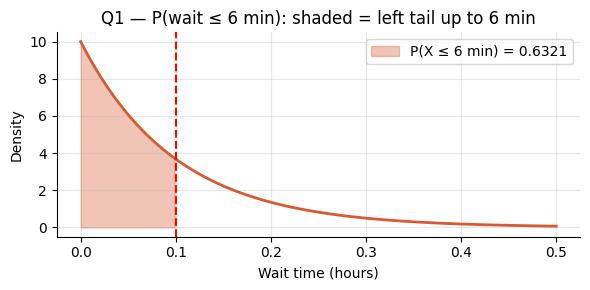

In [25]:
# Q1 — graph: shade LEFT of 6 min (0.1 hours)
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#D85A30', linewidth=2)
plt.fill_between(x, y, where=(x <= 0.1), alpha=0.35, color='#D85A30', label=f'P(X ≤ 6 min) = {expon.cdf(0.1,scale=mean_wait):.4f}')
plt.axvline(0.1, color='red', linestyle='--')
plt.title('Q1 — P(wait ≤ 6 min): shaded = left tail up to 6 min')
plt.xlabel('Wait time (hours)'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()


#### Q2 — What fraction of waits are MORE than 15 minutes?

"more than" = right tail → `1 - expon.cdf()`. Or use the shortcut: $P(X > x) = e^{-\lambda x}$

In [26]:
# Q2: P(X > 15 min)
q2 = 1 - expon.cdf(15/60, scale=mean_wait)


print(f'1 - expon.cdf(0.25, scale={mean_wait}) = {q2:.4f}')
print(f'→ Only {q2*100:.1f}% of waits exceed 15 minutes.')
print()
# Shortcut: P(X > x) = e^(-λx) — no scipy needed!
import math
shortcut = math.exp(-lam * (15/60))
print(f'Shortcut: e^(-λx) = e^(-{lam} × 0.25) = {shortcut:.4f}  ← same answer!')


1 - expon.cdf(0.25, scale=0.1) = 0.0821
→ Only 8.2% of waits exceed 15 minutes.

Shortcut: e^(-λx) = e^(-10 × 0.25) = 0.0821  ← same answer!


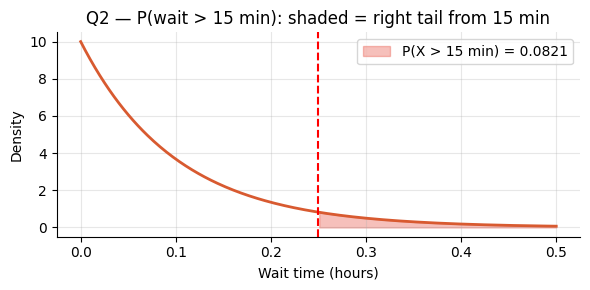

In [27]:
# Q2 — graph: shade RIGHT of 15 min (0.25 hours)
plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#D85A30', linewidth=2)
plt.fill_between(x, y, where=(x > 0.25), alpha=0.35, color='#e74c3c', label=f'P(X > 15 min) = {1-expon.cdf(0.25,scale=mean_wait):.4f}')
plt.axvline(0.25, color='red', linestyle='--')
plt.title('Q2 — P(wait > 15 min): shaded = right tail from 15 min')
plt.xlabel('Wait time (hours)'); plt.ylabel('Density'); plt.legend(); plt.tight_layout(); plt.show()


#### Q3 — What wait time marks the longest 10% of waits?

"longest 10%" means 90% of waits are shorter → we know the probability and want the x value → use `expon.ppf(0.90)`

In [28]:
# Q3: 90th percentile — top 10% of wait times
q3 = expon.ppf(0.90, scale=mean_wait)



print(f'expon.ppf(0.90, scale={mean_wait}) = {q3:.4f} hours = {q3*60:.1f} minutes')
print(f'→ Only 10% of waits are longer than {q3*60:.1f} minutes.')


expon.ppf(0.90, scale=0.1) = 0.2303 hours = 13.8 minutes
→ Only 10% of waits are longer than 13.8 minutes.


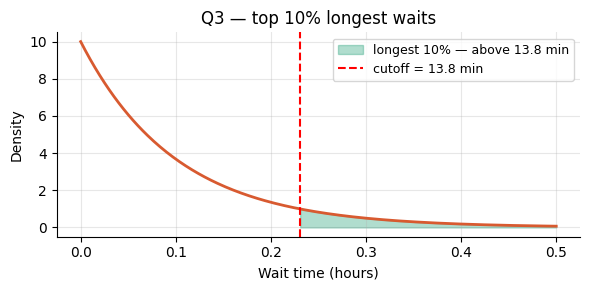

In [29]:
# Q3 — graph: shade the longest 10% of waits
cutoff = expon.ppf(0.90, scale=mean_wait)


plt.figure(figsize=(6, 3))
plt.plot(x, y, color='#D85A30', linewidth=2)
plt.fill_between(x, y, where=(x >= cutoff), alpha=0.35, color='#1D9E75', label=f'longest 10% — above {cutoff*60:.1f} min')
plt.axvline(cutoff, color='red', linestyle='--', label=f'cutoff = {cutoff*60:.1f} min')
plt.title('Q3 — top 10% longest waits')
plt.xlabel('Wait time (hours)'); plt.ylabel('Density'); plt.legend(fontsize=9); plt.tight_layout(); plt.show()


In [ ]:
# EXERCISE 4a — Fill in the blanks
#
# A printer breaks down on average once every 200 hours of use.
# Breakdowns follow an Exponential distribution.
#
# Q1: What is the rate λ (breakdowns per hour)?
# Q2: What is the probability it lasts more than 250 hours?
# Q3: What is the probability it breaks within the first 100 hours?
# Q4: What is the median time to breakdown?

mean_life = ___         # average hours until breakdown
lam_ex    = 1 / ___    # rate = 1 / mean

q2 = 1 - expon.cdf(___, scale=___)
q3 = expon.cdf(___, scale=___)
q4 = expon.ppf(___, scale=___)     # median = 50th percentile

print(f'Q1 λ                    = {lam_ex:.5f} per hour')
print(f'Q2 P(life > 250 hrs)    = {q2:.4f}')
print(f'Q3 P(breaks < 100 hrs)  = {q3:.4f}')
print(f'Q4 Median lifetime      = {q4:.2f} hours')

# ANSWERS:
# mean_life = 200, lam_ex = 0.005
# Q2: 1 - expon.cdf(250, scale=200) ≈ 0.2865
# Q3: expon.cdf(100, scale=200) ≈ 0.3935
# Q4: expon.ppf(0.5, scale=200) ≈ 138.63 hours

---
## Part 5 — Putting it all together: which distribution?

Use this decision tree every time:

```
Is the variable continuous or discrete?
│
├── CONTINUOUS
│     ├── Measuring a WAIT TIME between events?  →  Exponential
│     └── Natural measurement (height, score…)?  →  Normal
│
└── DISCRETE (a count)
      ├── Fixed number of trials n?              →  Binomial
      └── Events in a time/space interval?       →  Poisson
```

In [ ]:
# FINAL EXERCISE — Identify the distribution, then compute the answer
#
# For each scenario below:
#   (a) Write which distribution to use and why
#   (b) Fill in the Python code to answer the question

# --- Scenario A ---
# A coffee machine makes on average 1 breakdown per 500 uses.
# What is the probability it breaks within the first 300 uses?
# Distribution: ___  because ___

# Your code:
# ans_a = ...
# print(f'Scenario A: {ans_a:.4f}')

# --- Scenario B ---
# A student takes a 10-question true/false quiz and guesses every answer.
# What is the probability of passing (≥ 6 correct)?
# Distribution: ___  because ___

# Your code:
# ans_b = ...
# print(f'Scenario B: {ans_b:.4f}')

# --- Scenario C ---
# A city has on average 3 road accidents per day.
# What is the probability of 5 or more accidents tomorrow?
# Distribution: ___  because ___

# Your code:
# ans_c = ...
# print(f'Scenario C: {ans_c:.4f}')

# --- Scenario D ---
# Baby weights at birth have mean 3.4 kg and std 0.5 kg.
# What fraction of babies weigh more than 4 kg?
# Distribution: ___  because ___

# Your code:
# ans_d = ...
# print(f'Scenario D: {ans_d:.4f}')


# ANSWERS (distribution choices):
# A → Poisson: count of rare events (breakdowns) in fixed usage window (300 uses)
#   ans_a = 1 - poisson.cdf(0, mu=300/500)   # λ=0.6 for 300 uses
#   OR → Binomial: n=300 trials, p=1/500=0.002  (also valid, Poisson approx)
#   ans_a ≈ 0.4512
# B → Binomial: n=10 fixed trials, p=0.5, count correct answers
#   ans_b = 1 - binom.cdf(5, 10, 0.5)  ≈ 0.3770
# C → Poisson: count of events (accidents) per day with λ=3, no fixed n
#   ans_c = 1 - poisson.cdf(4, mu=3)  ≈ 0.1847
# D → Normal: continuous measurement clustering symmetrically around mean
#   ans_d = 1 - norm.cdf(4, loc=3.4, scale=0.5)  ≈ 0.1151

---
## Quick Cheat Sheet

| | Normal | Binomial | Poisson | Exponential |
|--|--------|----------|---------|-------------|
| **Type** | Continuous | Discrete | Discrete | Continuous |
| **What it models** | Natural measurements | Count of successes in n trials | Count of events in interval | Wait time between events |
| **Parameters** | μ, σ | n, p | λ | λ (scale=1/λ) |
| **Mean** | μ | n·p | λ | 1/λ |
| **Variance** | σ² | n·p·(1−p) | λ | 1/λ² |
| **Key words** | height, score, error | trials, flip, test | per hour, arrivals | wait time, lifetime |
| **scipy PDF/PMF** | `norm.pdf(x,μ,σ)` | `binom.pmf(k,n,p)` | `poisson.pmf(k,λ)` | `expon.pdf(x,scale=1/λ)` |
| **scipy CDF** | `norm.cdf(x,μ,σ)` | `binom.cdf(k,n,p)` | `poisson.cdf(k,λ)` | `expon.cdf(x,scale=1/λ)` |